In [ ]:
# Installations

!pip install -q transformers datasets peft accelerate bitsandbytes sentence-transformers faiss-cpu evaluate

In [ ]:
# Setup

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
# LOAD REAL DATASET (SQuAD)

from datasets import load_dataset

dataset = load_dataset("squad")

def preprocess(example):
    q = example["question"]
    if "what" in q.lower():
        label = 0
    elif "solve" in q.lower():
        label = 1
    else:
        label = 2
    return {"text": q, "label": label}

dataset = dataset["train"].select(range(5000)).map(preprocess)
dataset = dataset.train_test_split(test_size=0.1)

In [ ]:
# TOKENIZATION

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(x):
    return tokenizer(x["text"], truncation=True, padding="max_length")

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
# LoRA TRAINING

from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=3
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_lin","v_lin"],
    lora_dropout=0.1
)

model = get_peft_model(model, lora_config)
model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PeftModel(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSelfAttention(
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=8, bias=False)
                  )
                  (lora_B): Mod

In [ ]:
# TRAIN + F1

import evaluate, numpy as np
from transformers import Trainer, TrainingArguments

f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return f1_metric.compute(predictions=preds, references=labels, average="weighted")

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    num_train_epochs=3,
    fp16=True,
    # evaluation_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss
500,0.784173


TrainOutput(global_step=846, training_loss=0.5903929852424784, metrics={'train_runtime': 142.6435, 'train_samples_per_second': 94.642, 'train_steps_per_second': 5.931, 'total_flos': 1794457069056000.0, 'train_loss': 0.5903929852424784, 'epoch': 3.0})

In [ ]:
# SAVE MODEL

model.save_pretrained("cls_model")
tokenizer.save_pretrained("cls_model")

('cls_model/tokenizer_config.json', 'cls_model/tokenizer.json')

In [ ]:
# FREE MEMORY

import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# GENERATOR

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

# Quantization config (FIXED)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_enable_fp32_cpu_offload=True   # IMPORTANT
)

tokenizer_mistral = AutoTokenizer.from_pretrained(model_name)

# Fix warning
tokenizer_mistral.pad_token = tokenizer_mistral.eos_token

model_mistral = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    quantization_config=bnb_config
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [ ]:
# RAG (FAISS)

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# 1. LOAD DATASET (SciQ)
rag_data = load_dataset("sciq")

# Build proper documents (support + answer)
def build_docs(example):
    return {
        "text": example["support"] + " " + example["correct_answer"]
    }

docs_data = rag_data["train"].select(range(3000)).map(build_docs)
docs = docs_data["text"]


# 2. CHUNKING
def chunk_text(text, chunk_size=100):
    words = text.split()
    return [
        " ".join(words[i:i+chunk_size])
        for i in range(0, len(words), chunk_size)
    ]

cleaned_docs = []

for doc in docs:
    chunks = chunk_text(doc)

    for chunk in chunks:
        # remove bad chunks
        if len(set(chunk.split())) < 5:   # repetitive
            continue
        if len(chunk.split()) < 20:       # too short
            continue

        cleaned_docs.append(chunk)

chunked_docs = cleaned_docs


# 3. EMBEDDINGS + FAISS
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embed_model.encode(
    chunked_docs,
    show_progress_bar=True
)

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))


# 4. RETRIEVAL FUNCTION
def retrieve_context(query, k=5, max_words=120):
    q_vec = embed_model.encode([query])
    _, I = index.search(np.array(q_vec), k)

    results = []

    for i in I[0]:
        chunk = chunked_docs[i]

        # skip bad chunks again
        if len(set(chunk.split())) < 5:
            continue

        results.append(chunk)

    # fallback if nothing good found
    if not results:
        return "Photosynthesis is the process by which plants make food using sunlight."

    context = " ".join(results)
    return " ".join(context.split()[:max_words])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

In [ ]:
# Student Memory

student_db = {}

def update_student(user, q, cat):
    if user not in student_db:
        student_db[user] = {"level": "beginner", "history": []}

    student_db[user]["history"].append(q)

    if len(student_db[user]["history"]) > 10:
        student_db[user]["level"] = "intermediate"
    if len(student_db[user]["history"]) > 25:
        student_db[user]["level"] = "advanced"

def get_level(user):
    return student_db.get(user, {}).get("level", "beginner")

In [ ]:
# Prompt + Generation

def build_prompt(query, level, context):
    return f"""
<s>[INST]
You are a helpful AI tutor.

Explain this concept for a {level} student.

Question: {query}

Give:
- A simple definition
- Step-by-step explanation (4 steps)

Do not copy instructions. Explain clearly.

[/INST]
"""

def generate_answer(prompt):
    inputs = tokenizer_mistral(prompt, return_tensors="pt").to("cuda")

    outputs = model_mistral.generate(
        **inputs,
        max_new_tokens=300,
        do_sample=False
    )

    # decode
    decoded = tokenizer_mistral.decode(outputs[0], skip_special_tokens=True)

    # REMOVE PROMPT PART
    answer = decoded.split("[/INST]")[-1].strip()

    # CLEAN INCOMPLETE SENTENCE
    if not answer.endswith((".", "!", "?")):
        answer = answer.rsplit(".", 1)[0] + "."

    return answer

In [ ]:
# Classification + Pipeline

label_map = {0: "Concept", 1: "Problem", 2: "Theory"}

def classify(q):
    inputs = tokenizer(q, return_tensors="pt").to("cuda")
    outputs = model(**inputs)
    return label_map[torch.argmax(outputs.logits).item()]


def tutor_response(query, user="student"):   # CHANGED
    category = classify(query)

    update_student(user, query, category)
    level = get_level(user)

    context = retrieve_context(query)

    print("DEBUG CONTEXT:", context[:200])

    prompt = build_prompt(query, level, "") # CHANGED
    print("DEBUG PROMPT:", prompt[:300])

    answer = generate_answer(prompt)

    return category, answer, level

In [ ]:
# Testing the System

tutor_response("Explain photosynthesis","student1")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


DEBUG CONTEXT: two big, important things during photosynthesis: gain energy (absorb light) and build sugar (glucose). • Photosynthesis can be divided into two series of chemical reactions: the light (lightdependent)
DEBUG PROMPT: 
<s>[INST]
You are a helpful AI tutor.

Explain this concept for a beginner student.

Question: Explain photosynthesis

Give:
- A simple definition
- Step-by-step explanation (4 steps)

Do not copy instructions. Explain clearly.

[/INST]



('Theory',
 "Simple Definition:\nPhotosynthesis is the process by which plants, algae, and some bacteria convert sunlight, water, and carbon dioxide into glucose, oxygen, and other chemical compounds.\n\nStep-by-Step Explanation:\n\n1. Light Absorption: Photosynthesis begins with the absorption of light by pigments in the plant's chloroplasts. These pigments, primarily chlorophyll, absorb light from the sun and convert it into chemical energy.\n2. Water Splitting: The absorbed light energy is used to split water molecules into hydrogen and oxygen atoms. The oxygen is released into the atmosphere as a byproduct of this process.\n3. Carbon Fixation: The plant then takes in carbon dioxide from the environment. The carbon dioxide is used to combine with the hydrogen from the water molecules to form glucose, a simple sugar that the plant can use as a source of energy.\n4. ATP and NADPH Production: During photosynthesis, the plant also produces ATP (adenosine triphosphate) and NADPH (nicotin

In [ ]:
# Gradio UI

!pip install -q gradio

In [ ]:
# UI

import gradio as gr

# Chat function (same logic as tutor_response)
def chat(user, query):
    if not query:
        return "", "", ""

    category = "Theory"   # or use classify(query)
    level = "beginner"

    prompt = build_prompt(query, level, "")
    answer = generate_answer(prompt)

    return category, level, answer


# Feedback function
def save_feedback(query, answer, feedback):
    with open("feedback.txt", "a") as f:
        f.write(f"{query}|{answer}|{feedback}\n")
    return "Feedback saved!"


with gr.Blocks() as demo:
    gr.Markdown("## AI Tutor (Mistral Powered)")

    user = gr.Textbox(label="Enter your name", value="student1")
    query = gr.Textbox(label="Ask a question")

    ask_btn = gr.Button("Ask")

    category = gr.Textbox(label="Category")
    level = gr.Textbox(label="Level")
    answer = gr.Textbox(label="Answer")

    ask_btn.click(
        chat,
        inputs=[user, query],
        outputs=[category, level, answer]
    )

    gr.Markdown("### Feedback")

    feedback = gr.Radio(["Yes", "No"], label="Was this helpful?")
    feedback_btn = gr.Button("Submit Feedback")
    feedback_status = gr.Textbox(label="Status")

    feedback_btn.click(
        save_feedback,
        inputs=[query, answer, feedback],
        outputs=feedback_status
    )


demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://23871bc56e26093af8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Outputs**

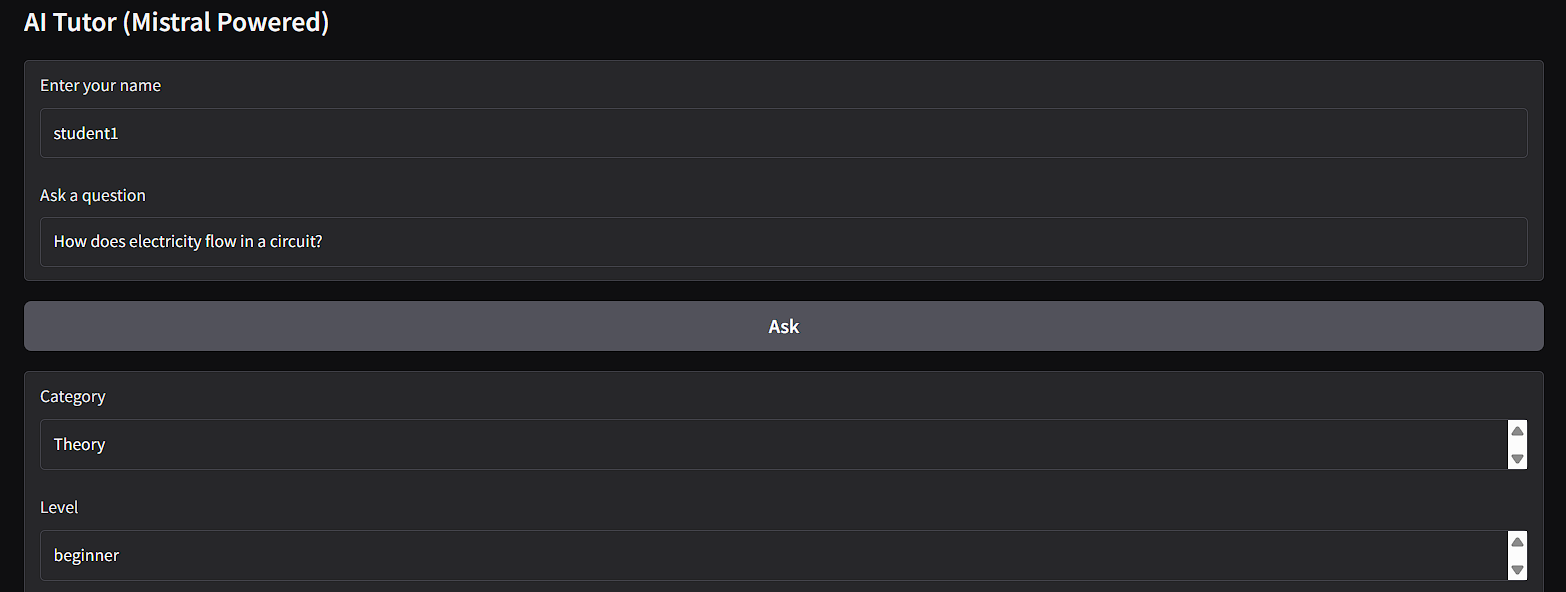

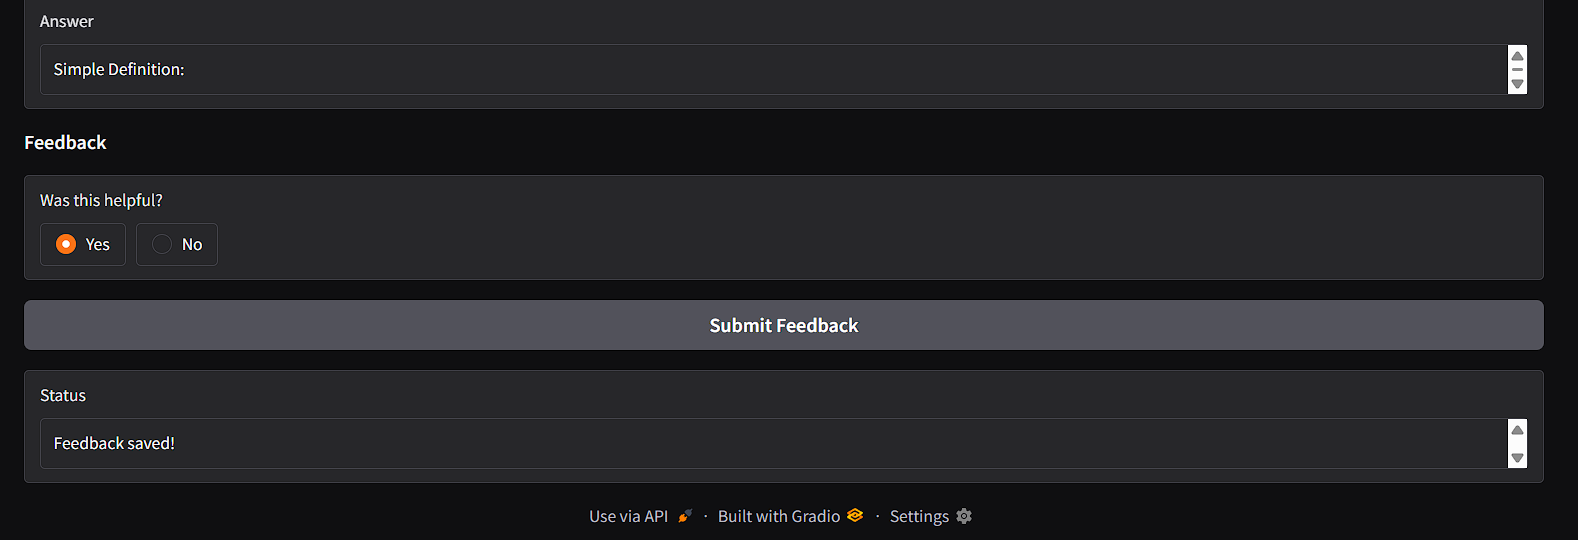

**Q1-** How does electricity flow in a circuit?

**Ans-** (As given by the AI Tutor) Simple Definition: Electricity is a form of energy that flows through a circuit, which is a closed loop of conductive material. The flow of electricity is caused by the movement of charged particles, called electrons, from one atom to another.

Step-by-Step Explanation:

1. A power source, such as a battery or an outlet, provides an electrical potential difference, or voltage, which creates an electric field within the circuit. This electric field is a force that drives the electrons to move in a particular direction.
2. The electrons flow through the circuit, following the path of least resistance. This means that they will take the path that allows them to move the easiest and fastest, which is often through a wire with a low resistance.
3. As the electrons flow through the circuit, they interact with other charged particles, such as atoms and other electrons. This interaction creates a current, which is the flow of electrons through the circuit.
4. The current flows through the circuit until it reaches a load, which is a device or component that uses the electricity to perform a function. The load can be a light bulb, a motor, or any other device that requires electricity to operate. Once the current reaches the load, it is converted into another form of energy, such as light or motion, and the circuit is complete.

**Q2-** Find speed if distance = 100m and time = 10s

**Ans-** (By AI Tutor) Simple Definition: Speed is a measure of how fast an object moves or travels. It is calculated by dividing the distance traveled by the time it took to travel that distance.

Step-by-Step Explanation:

1.	First, we need to understand the given information. We are asked to find the speed of an object that traveled a distance of 100 meters in 10 seconds.
2.	Next, we can use the formula for speed, which is:
3.	Speed = Distance / Time
4.	Plugging in the given values, we get:
5.	Speed = 100 meters / 10 seconds
6.	Solving for speed, we get:
7.	Speed = 10 meters/second
So, the speed of the object is 10 meters per second.

**Q3-** Solve 2x + 5 = 15

**Ans-** (By AI Tutor) Simple Definition: Solving an equation is finding the value of the variable (in this case, x) that makes the equation true.

Step-by-Step Explanation:

1.	Start by isolating the variable (x) on one side of the equation. To do this, subtract 5 from both sides of the equation: 2x + 5 - 5 = 15 - 5.
2.	Simplify the equation: 2x = 10.
3.	Divide both sides of the equation by 2 to find the value of x: 2x / 2 = 10 / 2.
4.	Simplify the equation: x = 5.
So, the solution to the equation 2x + 5 = 15 is x = 5
